# Vectors: arrows, journeys and proofs

Over the next few sessions you're going to learn what vectors are, how to add them, stretch them and flip them, and how to use them to **prove** things about shapes. That last part is what the hardest GCSE vector questions ask for.

Each session works the same way:

1. **Watch** part of a 3Blue1Brown video.
2. **Predict** on paper what you think will happen.
3. **Experiment** by changing the code in the notebooks and seeing whether you were right.
4. **Explain** by answering questions without the computer.

You don't need to understand any of the code. The lines you're meant to change will be clearly marked. Breaking things is fine. That's what the experimenting part is for.

## The videos

These come from Grant Sanderson's (3Blue1Brown) series *Essence of Linear Algebra*. Watch them properly: pause, rewind, and try to guess what's coming next.

| # | Video | When | Length |
|---|---|---|---|
| 1 | **Vectors, what even are they?** [YouTube](https://www.youtube.com/watch?v=fNk_zzaMoSs) · [lesson page](https://www.3blue1brown.com/lessons/vectors) | Sessions 1–2 | ~10 min |
| 2 | **Linear combinations, span, and basis vectors** [YouTube](https://www.youtube.com/watch?v=k7RM-ot2NWY) · [lesson page](https://www.3blue1brown.com/lessons/span) | Session 4 | ~10 min |
| 3 | *(Bonus)* **Linear transformations and matrices** [YouTube](https://www.youtube.com/watch?v=kYB8IZa5AuE) · [lesson page](https://www.3blue1brown.com/lessons/linear-transformations) | Optional session 6 | ~11 min |

The full playlist is [here](https://www.youtube.com/playlist?list=PLZHQObOWTQDPD3MizzM2xVFitgF8hE_ab) if you want to keep going.



## Writing vectors on paper

Typed text and exam papers show vectors in **bold**: $\mathbf{a}$. You can't write bold by hand, so **underline** them instead: $\underline{a}$. Examiners expect this.

A vector can also be written as a **column vector**. This one means "3 right, 2 up":

$$\begin{pmatrix} 3 \\ 2 \end{pmatrix}$$

Notice that it's written in brackets, stacked vertically. That's different from the coordinate $(3, 2)$, which is a *place*, not a *movement*. Working out exactly how those two differ is the first thing we'll do.

## Setup check

Run the next two cells (click the cell, then press **Shift + Enter**). If both work, you're ready.

The first cell draws a vector with **matplotlib**, which we'll use for quick experiments.

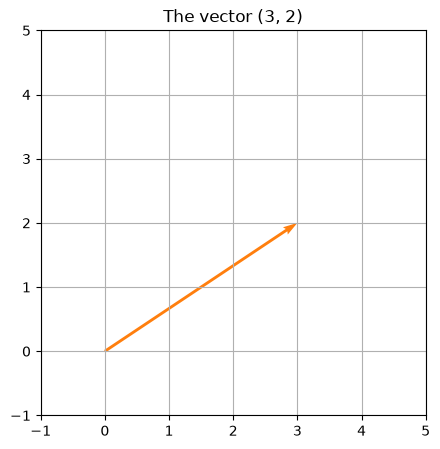

In [1]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 5))
ax.quiver(0, 0, 3, 2, angles="xy", scale_units="xy", scale=1, color="tab:orange")
ax.set_xlim(-1, 5)
ax.set_ylim(-1, 5)
ax.set_aspect("equal")
ax.grid(True)
ax.set_title("The vector (3, 2)")
plt.show()

### Count the squares in the above image and explain why that vector is $\begin{pmatrix} 3 \\ 2 \end{pmatrix}$

The second cell animates the same vector with **manim**, the library 3Blue1Brown uses to make his videos. Rendering takes a few seconds.

In [2]:
from manim import *

config.media_embed = True

In [3]:
%%manim -ql -v WARNING --progress_bar none FirstVector
x = 3
y = 2
xdir = " "
ydir = " "
if x > 0:
    xdir = "right"
elif x < 0:
    xdir = "left"
if y > 0:
    ydir = "up"
elif y < 0:
    ydir = "down"

class FirstVector(Scene):
    def construct(self):
        plane = NumberPlane()
        v = Arrow(plane.c2p(0, 0), plane.c2p(x, y), buff=0, color=YELLOW)
        label = Text(f"{abs(x)} {xdir}, {abs(y)} {ydir}", font_size=28).next_to(v.get_end(), RIGHT)
        self.add(plane)
        self.play(GrowArrow(v))
        self.play(Write(label))
        self.wait()

Manim Community v0.21.0

Try your first change: edit the `x=3, y=2` on the second and third lines to a different pair of numbers (try a negative one) and run the cell again. Where did the arrow go? What happens if you select 0 for one of those? What happens if you select 0 for both? First predict what would happen then run the animation. Did you predict it correctly?

Once both cells work, you're ready to start.

## What a column vector really means

The arrow to $(3, 2)$ goes diagonally. But you can also get to the same place in two steps: **first across, then up**.

The animation below does exactly that. It draws the "across" move in green, then the "up" move in red, starting from where the green one ended. Then it draws the total movement in yellow.

**Before you run it:** where will the yellow arrow end? How do you think the numbers in the column vector will be connected to the green and red moves?

In [4]:
%%manim -ql -v WARNING --progress_bar none AcrossThenUp

# ✏️ Change these
x = 3
y = 2


class AcrossThenUp(Scene):
    def construct(self):
        plane = NumberPlane()
        self.add(plane, Dot(plane.c2p(0, 0)))

        # Step 1: across (green)
        if x != 0:
            across = Arrow(plane.c2p(0, 0), plane.c2p(x, 0), buff=0, color=GREEN)
            x_num = Text(str(abs(x)), font_size=30, color=GREEN)
            x_word = Text("right" if x > 0 else "left", font_size=30, color=GREEN)
            x_label = VGroup(x_num, x_word).arrange(RIGHT, buff=0.15)
            x_label.next_to(across, DOWN if y >= 0 else UP).add_background_rectangle()
            self.play(GrowArrow(across), FadeIn(x_label))
        else:
            x_num = Text("0", font_size=30, color=GREEN).move_to(plane.c2p(0, 0)).set_opacity(0)

        # Step 2: up (red), starting where the green arrow ended
        if y != 0:
            up = Arrow(plane.c2p(x, 0), plane.c2p(x, y), buff=0, color=RED)
            y_num = Text(str(abs(y)), font_size=30, color=RED)
            y_word = Text("up" if y > 0 else "down", font_size=30, color=RED)
            y_label = VGroup(y_num, y_word).arrange(RIGHT, buff=0.15)
            y_label.next_to(up, RIGHT if x >= 0 else LEFT).add_background_rectangle()
            self.play(GrowArrow(up), FadeIn(y_label))
        else:
            y_num = Text("0", font_size=30, color=RED).move_to(plane.c2p(x, 0)).set_opacity(0)

        # Step 3: the total movement (yellow)
        if (x, y) != (0, 0):
            total = Arrow(plane.c2p(0, 0), plane.c2p(x, y), buff=0, color=YELLOW)
            self.play(GrowArrow(total))

        # Step 4: the numbers fly into the column vector
        top = Text(str(x).replace("-", "−"), font_size=40, color=GREEN)
        bottom = Text(str(y).replace("-", "−"), font_size=40, color=RED)
        entries = VGroup(top, bottom).arrange(DOWN, buff=0.25)
        left_bracket = Text("(", font_size=40).stretch_to_fit_height(entries.height * 1.3)
        right_bracket = Text(")", font_size=40).stretch_to_fit_height(entries.height * 1.3)
        left_bracket.next_to(entries, LEFT, buff=0.15)
        right_bracket.next_to(entries, RIGHT, buff=0.15)
        heading = Text("total movement =", font_size=30, color=YELLOW)
        column = VGroup(heading, VGroup(left_bracket, entries, right_bracket)).arrange(RIGHT)
        # Put it in the corner away from the arrows
        column.to_corner(UL if x >= 0 else UR).add_background_rectangle(opacity=0.85, buff=0.2)

        self.play(FadeIn(column.background_rectangle), FadeIn(heading), FadeIn(left_bracket), FadeIn(right_bracket))
        self.play(TransformFromCopy(x_num, top), TransformFromCopy(y_num, bottom), run_time=1.5)
        self.wait()

Manim Community v0.21.0

Now experiment. Predict first each time, then run it.

1. Try `x = -4`, `y = 1`. What does the minus sign in the column vector tell you?
2. Try `x = 2`, `y = -3`. Which way does the red arrow go now?
3. Try `x = 0`, `y = 3`. What happens to the green step?
4. Find an `x` and `y` that put the yellow arrow pointing straight down-left at 45°.

> ### Definition: column vector
>
> A **column vector** describes a movement as two steps:
>
> $$\begin{pmatrix} \text{across} \\ \text{up} \end{pmatrix}$$
>
> - The **top** number is the horizontal step: positive means **right**, negative means **left**.
> - The **bottom** number is the vertical step: positive means **up**, negative means **down**.
>
> So $\begin{pmatrix} 3 \\ 2 \end{pmatrix}$ literally means "3 right, then 2 up", and $\begin{pmatrix} -4 \\ 1 \end{pmatrix}$ means "4 left, then 1 up".

Going across first and then up is just one way to make the journey. Try it in your head: if you go up first and then across, do you end up in the same place?

### Check yourself (no computer)

1. Write "5 left, 2 down" as a column vector.
2. Describe $\begin{pmatrix} 0 \\ -6 \end{pmatrix}$ in words.
3. A vector goes from $(1, 1)$ to $(4, 6)$. Write it as a column vector.

## How long is a vector?

A vector has a **size** and a **direction**. The column vector tells you the direction straight away. But how long is the yellow arrow?

Look back at the green, red and yellow arrows from the last animation. What shape do they make?

**Before you run it:** estimate the length of $\begin{pmatrix} 3 \\ 2 \end{pmatrix}$ by eye. Between which two whole numbers is it? Then work it out on paper.

*This isn't on your GCSE spec, but A-level uses it all the time. And the method is something you already know.*

In [ ]:
%%manim -ql -v WARNING --progress_bar none HowLong
import math

# ✏️ Change these
x = 3
y = 2


def signed(n):
    # Negative numbers need brackets when squared: (−4)², not −4²
    return f"(−{abs(n)})" if n < 0 else str(n)


class HowLong(Scene):
    def construct(self):
        plane = NumberPlane()
        self.add(plane, Dot(plane.c2p(0, 0)))
        origin, corner, tip = plane.c2p(0, 0), plane.c2p(x, 0), plane.c2p(x, y)

        # The across-then-up triangle from before, drawn straight away
        if x != 0:
            self.add(Arrow(origin, corner, buff=0, color=GREEN))
            self.add(Text(str(abs(x)), font_size=30, color=GREEN)
                     .next_to(Line(origin, corner), DOWN if y >= 0 else UP)
                     .add_background_rectangle())
        if y != 0:
            self.add(Arrow(corner, tip, buff=0, color=RED))
            self.add(Text(str(abs(y)), font_size=30, color=RED)
                     .next_to(Line(corner, tip), RIGHT if x >= 0 else LEFT)
                     .add_background_rectangle())
        if (x, y) != (0, 0):
            self.add(Arrow(origin, tip, buff=0, color=YELLOW))
        if x != 0 and y != 0:
            self.play(Create(RightAngle(Line(corner, origin), Line(corner, tip), length=0.3)))

        # A "?" on the yellow arrow, on the side away from the right angle
        middle = (origin + tip) / 2
        if x == 0:
            away = LEFT  # no triangle: the red label is on the right
        elif y == 0:
            away = UP  # no triangle: the green label is underneath
        else:
            away = (middle - corner) / np.linalg.norm(middle - corner)
        question = Text("?", font_size=36, color=YELLOW).move_to(middle + 0.45 * away)
        self.play(Write(question))

        # Pythagoras, one line at a time
        total = x**2 + y**2
        length = math.sqrt(total)
        if length == int(length):
            answer = f"= {int(length)}"
            short = str(int(length))
        else:
            answer = f"≈ {length:.2f}"
            short = f"{length:.2f}"
        first_rest = Text(f"= √({signed(x)}² + {signed(y)}²)", font_size=30)
        line1 = VGroup(Text("length", font_size=30), first_rest).arrange(RIGHT, buff=0.15)
        line2 = Text(f"= √{total}", font_size=30)
        line3 = Text(answer, font_size=30, color=YELLOW)
        working = VGroup(line1, line2, line3).arrange(DOWN, aligned_edge=LEFT)
        for line in (line2, line3):
            line.align_to(first_rest, LEFT)  # line up the "=" signs
        working.to_corner(UL if x >= 0 else UR).add_background_rectangle(opacity=0.85, buff=0.2)

        self.play(FadeIn(working.background_rectangle), Write(line1))
        self.play(Write(line2))
        self.play(Write(line3))
        self.play(Transform(question, Text(short, font_size=30, color=YELLOW)
                            .move_to(middle + 0.55 * away).add_background_rectangle()))
        self.wait()

### Why more than 3?

The answer $3.61$ is more than $3$, and it **had** to be. Look at the squares:

$$|\mathbf{a}|^2 = 3^2 + 2^2 = 9 + 4 = 13, \quad \text{which is more than } 3^2 = 9.$$

The green step contributes $9$, and the red step adds another $4$ on top. So the yellow arrow must be longer than the green one. It's **strictly** longer because $2^2$ is more than $0$. The only way to get exactly $3$ would be if the up step were $0$.

This is the same fact you already know about right-angled triangles: the hypotenuse is always the longest side.

Now experiment. Predict first each time, then run it.

1. Try `x = -4`, `y = 1`. Why does the working put brackets around the $-4$? What would go wrong without them?
2. Is $\begin{pmatrix} 3 \\ 2 \end{pmatrix}$ the same length as $\begin{pmatrix} 2 \\ 3 \end{pmatrix}$? What about $\begin{pmatrix} -3 \\ -2 \end{pmatrix}$?
3. The yellow arrow is longer than the green one. Is it always longer than the red one too? Is it ever longer than going green-then-red, which is $3 + 2 = 5$? Try a few vectors, including some with a $0$, and see whether the pattern always holds.

> ### Definition: magnitude
>
> The **magnitude** of a vector is its length. For a vector $\mathbf{a}$, it is written $|\mathbf{a}|$.
>
> If $\mathbf{a} = \begin{pmatrix} x \\ y \end{pmatrix}$, then by Pythagoras:
>
> $$|\mathbf{a}| = \sqrt{x^2 + y^2}$$
>
> The minus signs never matter, because squaring a negative number gives a positive one. Flipping a vector round changes its direction, but not its length.
>
> **A quick check for any answer.** Ignoring minus signs, the length is
> - **at least** the bigger of the two numbers, because the hypotenuse is the longest side, and
> - **at most** the two numbers added together, because going straight is never longer than going across and then up.
>
> For $\begin{pmatrix} 3 \\ 2 \end{pmatrix}$: $3 < \sqrt{13} < 5$. You only get "equal" when one of the numbers is $0$.

Now use the formula: search on paper first, then check your answers with the animation.

1. Find a vector whose length is exactly a **whole number**, without lying flat along an axis.
2. Find **three different** vectors that all have length 5.

### Check yourself (no computer)

1. Find the magnitude of $\begin{pmatrix} 6 \\ -8 \end{pmatrix}$.
2. Without calculating, which is longer: $\begin{pmatrix} 5 \\ 1 \end{pmatrix}$ or $\begin{pmatrix} -1 \\ -5 \end{pmatrix}$? Explain.
3. A vector goes from $(1, 1)$ to $(4, 5)$. Write it as a column vector, then find its length.

## The zero vector

Every vector you've drawn so far has a **length** and a **direction**. That's what a vector is: something with a size and a direction.

But when you set `x = 0` and `y = 0`, the arrow disappeared. So what is that "vector", and does it count?

In the animation below, a dot goes on a journey made of several moves. Each pink arrow is one move. At the end, a yellow arrow goes straight from where the dot **started** to where it **finished**: that's its **total movement**.

**Before you run it:** the moves are 3 right 2 up, then 3 left 2 down. Where does the dot finish? What will the yellow arrow look like? Write your prediction down.

In [ ]:
%%manim -ql -v WARNING --progress_bar none ThereAndBack

# ✏️ Change these
start = (-2, -1)
moves = [(3, 2), (-3, -2)]


def describe(x, y):
    # (3, -2) -> "3 right, 2 down"
    parts = []
    if x != 0:
        parts.append(f"{abs(x)} {'right' if x > 0 else 'left'}")
    if y != 0:
        parts.append(f"{abs(y)} {'up' if y > 0 else 'down'}")
    return ", ".join(parts)


class ThereAndBack(Scene):
    def construct(self):
        plane = NumberPlane()
        self.add(plane, Dot(plane.c2p(*start), color=WHITE))
        dot = Dot(plane.c2p(*start), color=YELLOW, radius=0.12)
        self.add(dot)

        here = start
        for dx, dy in moves:
            if (dx, dy) == (0, 0):
                # A move of nothing: the dot stays put
                self.play(Indicate(dot))
                continue
            new = (here[0] + dx, here[1] + dy)
            step = Arrow(plane.c2p(*here), plane.c2p(*new), buff=0, color=PINK)
            self.play(GrowArrow(step), dot.animate.move_to(plane.c2p(*new)))
            here = new

        total = (here[0] - start[0], here[1] - start[1])
        if total == (0, 0):
            message = Text("Back where it started: the total movement is the zero vector", font_size=26)
            self.play(Flash(dot, color=YELLOW))
        else:
            self.play(GrowArrow(Arrow(plane.c2p(*start), plane.c2p(*here), buff=0, color=YELLOW)))
            message = Text(f"Total movement: {describe(*total)}", font_size=26)
        message.to_edge(UP).add_background_rectangle()
        self.play(Write(message))
        self.wait()

Now experiment. Predict first each time, then run it.

1. Make a journey of **three** moves that ends where it started.
2. Do it again, but this time no move is allowed to simply undo another one.
3. Add the move `(0, 0)` somewhere in the list. What happens to the dot? Does it change where the journey finishes?
4. Change `start`. Does that change whether the dot ends up back where it started?

> ### Definition: the zero vector
>
> The **zero vector** is the movement "don't move at all":
>
> $$\mathbf{0} = \begin{pmatrix} 0 \\ 0 \end{pmatrix}$$
>
> By hand, write it as an underlined $\underline{0}$, just like any other vector.
>
> - It's the only vector with **length 0**, and it has **no direction**. That's why it can't be drawn as an arrow.
> - Any journey that ends where it started has a total movement of $\mathbf{0}$, however long the journey was.
> - Adding $\mathbf{0}$ to a journey changes nothing. That's what the `(0, 0)` move showed you.

**Careful:** the point $(0, 0)$ (the origin) is a **place**. The zero vector $\begin{pmatrix} 0 \\ 0 \end{pmatrix}$ is a **movement**, and you can "do" it starting anywhere. They're written with the same numbers, but they are different things.

### Check yourself (no computer)

1. A dot moves $\begin{pmatrix} 4 \\ 1 \end{pmatrix}$, then $\begin{pmatrix} -1 \\ 3 \end{pmatrix}$, then one more move, and ends up exactly where it started. What was the third move?
2. True or false: "The zero vector and the point $(0, 0)$ are the same thing." Explain your answer.
3. Sam walks 2 km to school and 2 km back home along the same road. How far did Sam **travel**? What was Sam's **total movement** as a vector?

## Equal vectors

The animation draws the vector $\begin{pmatrix} 3 \\ 2 \end{pmatrix}$ starting from the origin, then slides a copy of it to some other starting points.

**Before you run it:** when the arrow moves to a new starting point, does it become a different vector?

In [ ]:
%%manim -ql -v WARNING --progress_bar none SameVector

# ✏️ Change these
v = (3, 2)
starts = [(0, 0), (-5, -2), (2, -3)]


class SameVector(Scene):
    def construct(self):
        plane = NumberPlane()
        self.add(plane)

        first = Arrow(plane.c2p(*starts[0]), plane.c2p(starts[0][0] + v[0], starts[0][1] + v[1]),
                      buff=0, color=YELLOW)
        self.add(Dot(plane.c2p(*starts[0])))
        self.play(GrowArrow(first))

        for s in starts[1:]:
            self.add(Dot(plane.c2p(*s)))
            self.play(first.copy().animate.shift(plane.c2p(*s) - plane.c2p(*starts[0])))

        across = f"{abs(v[0])} {'right' if v[0] >= 0 else 'left'}"
        up = f"{abs(v[1])} {'up' if v[1] >= 0 else 'down'}"
        message = Text(f"Every arrow is the same vector: {across}, {up}", font_size=26)
        self.play(Write(message.to_edge(UP).add_background_rectangle()))
        self.wait()

Now experiment. Predict first each time, then run it.

1. Add a starting point of your own to `starts`. Will the copy fit exactly?
2. What would you have to change to get a **different** vector: the starting point, or `v`?

> ### Definition: equal vectors
>
> Two vectors are **equal** if they have the same column vector, which means the **same length** and the **same direction**. Where the arrow starts doesn't matter.
>
> So the arrow from $(1, 1)$ to $(4, 3)$ is the same vector as the arrow from $(0, 0)$ to $(3, 2)$: both are $\begin{pmatrix} 3 \\ 2 \end{pmatrix}$.

### Check yourself (no computer)

1. Which of these arrows are equal to $\begin{pmatrix} 2 \\ -1 \end{pmatrix}$?
   - from $(0, 0)$ to $(2, -1)$
   - from $(3, 3)$ to $(5, 2)$
   - from $(1, 0)$ to $(-1, 1)$

## End of session 1

Next time: `02-adding-journeys.ipynb`, where you'll flip vectors round, add them together and stretch them.